In [1]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sys.path.append("..")

import importlib
import src.preprocessing.pipeline as pl
importlib.reload(pl)

build_preprocessing_pipeline = pl.build_preprocessing_pipeline
get_feature_lists = pl.get_feature_lists

set_config(transform_output="pandas")

DATA_PATH = "../data/processed/health_index_ae_dataset.csv"
MODELS_PATH = "../models"
REPORTS_PATH = "../reports"

os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(REPORTS_PATH, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)

In [2]:
df_model = pd.read_csv(DATA_PATH)

print(df_model.shape)
df_model.head()

(24042, 24)


,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,...,temp_gap,vibration_rpm_interaction,pressure_current_interaction,vibration_delta,temperature_delta,anomaly_trend_raw,reconstruction_error,reconstruction_error_norm,health_index_ae,health_status
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,...,35.61,697.329,120.360,0.00,0.00,0.000,0.000004,0.004974,0.995026,good
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,...,30.38,674.700,125.080,-0.06,-8.93,0.000,0.000004,0.004555,0.995445,good
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,...,36.10,612.517,NaN,-0.04,9.12,3.648,0.000003,0.003181,0.996819,good
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,...,29.64,661.504,108.254,0.05,-6.66,0.030,0.000003,0.003954,0.996046,good
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,...,30.59,776.072,98.568,0.12,-1.65,0.072,0.000003,0.003573,0.996427,good


In [3]:
print(df_model.columns.tolist())
print(df_model["health_index_ae"].describe())
print(df_model["health_status"].value_counts())

['timestamp', 'machine_id', 'machine_type', 'vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'operating_mode', 'hours_since_maintenance', 'ambient_temp', 'rul_hours', 'failure_within_24h', 'failure_type', 'temp_gap', 'vibration_rpm_interaction', 'pressure_current_interaction', 'vibration_delta', 'temperature_delta', 'anomaly_trend_raw', 'reconstruction_error', 'reconstruction_error_norm', 'health_index_ae', 'health_status']
count    24042.000000
mean         0.967134
std          0.123830
min          0.000000
25%          0.984992
50%          0.992597
75%          0.996977
max          1.000000
Name: health_index_ae, dtype: float64
health_status
good        23315
critical      455
warning       272
Name: count, dtype: int64


In [4]:
target = "health_index_ae"
numeric_features, categorical_features = get_feature_lists()
all_features = numeric_features + categorical_features

available_features = [col for col in all_features if col in df_model.columns]

print("Nombre de features disponibles :", len(available_features))
print(available_features)

Nombre de features disponibles : 15
['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp', 'temp_gap', 'vibration_rpm_interaction', 'pressure_current_interaction', 'vibration_delta', 'temperature_delta', 'anomaly_trend_raw', 'machine_type', 'operating_mode']


In [5]:
forbidden_cols = [
    "health_index_ae",
    "health_status",
    "reconstruction_error",
    "reconstruction_error_norm",
    "failure_within_24h",
]

available_features = [col for col in available_features if col not in forbidden_cols]

print("Features finales utilisées :", len(available_features))
print(available_features)

Features finales utilisées : 15
['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp', 'temp_gap', 'vibration_rpm_interaction', 'pressure_current_interaction', 'vibration_delta', 'temperature_delta', 'anomaly_trend_raw', 'machine_type', 'operating_mode']


In [6]:
X = df_model[available_features].copy()
y = df_model[target].copy()

print("Shape X :", X.shape)
print("Shape y :", y.shape)

Shape X : (24042, 15)
Shape y : (24042,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train :", X_train.shape, y_train.shape)
print("Test  :", X_test.shape, y_test.shape)

Train : (19233, 15) (19233,)
Test  : (4809, 15) (4809,)


In [8]:
preprocessor = build_preprocessing_pipeline()
print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['vibration_rms', 'temperature_motor',
                                  'current_phase_avg', 'pressure_level', 'rpm',
                                  'hours_since_maintenance', 'ambient_temp',
                                  'temp_gap', 'vibration_rpm_interaction',
                                  'pressure_current_interaction',
                                  'vibration_delta', 'temperature_delta',
                                  'anomaly_trend_raw']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                       

In [9]:
models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ),

    "MLP Regressor": MLPRegressor(
        hidden_layer_sizes=(64, 32),
        max_iter=300,
        random_state=42
    )
}

In [10]:
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2

In [11]:
results = []
trained_models = {}
predictions = {}

for name, model in models.items():
    print(f"\nTraining : {name}")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae, rmse, r2 = compute_metrics(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    trained_models[name] = pipeline
    predictions[name] = y_pred

print("\nEntraînement terminé.")


Training : Linear Regression

Training : Random Forest

Training : Gradient Boosting

Training : MLP Regressor

Entraînement terminé.


In [12]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="RMSE", ascending=True).reset_index(drop=True)

results_df

,Model,MAE,RMSE,R2
0,Random Forest,0.008928,0.049343,0.855924
1,MLP Regressor,0.024295,0.061650,0.775093
2,Gradient Boosting,0.018992,0.068023,0.726191
3,Linear Regression,0.049904,0.114882,0.219010


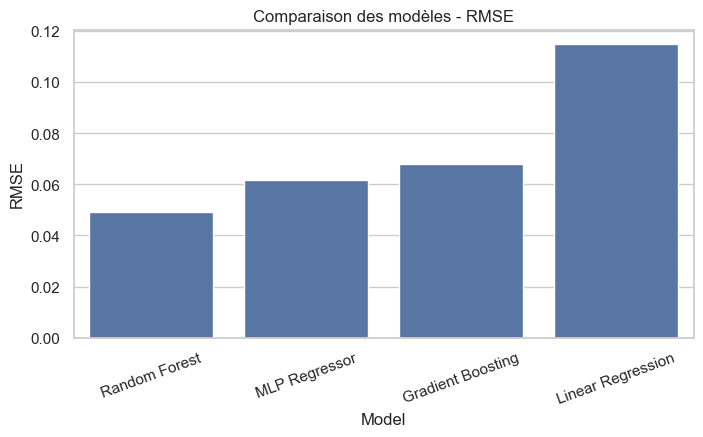

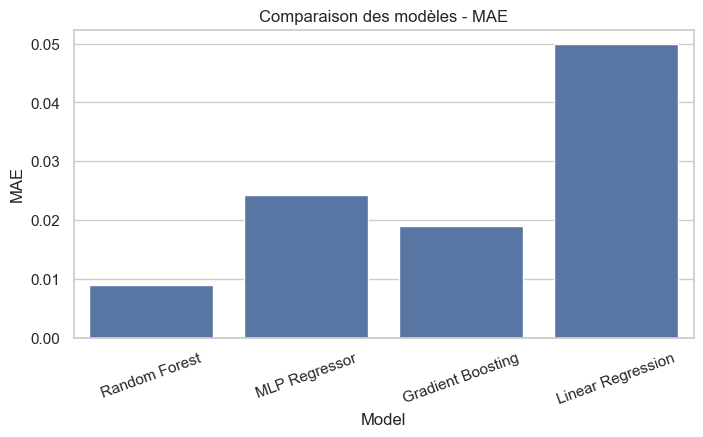

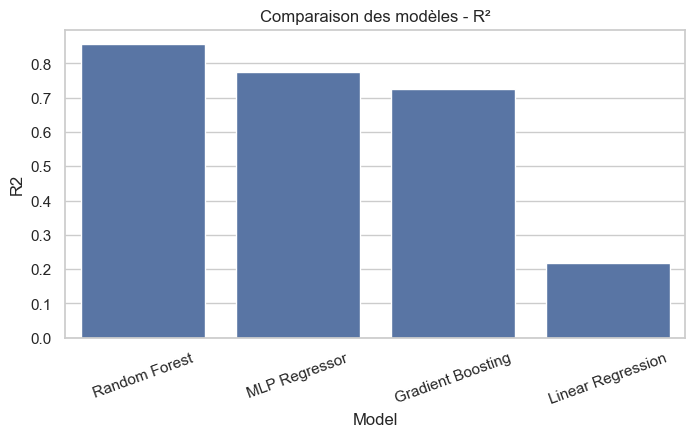

In [14]:
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="Model", y="RMSE")
plt.title("Comparaison des modèles - RMSE")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="Model", y="MAE")
plt.title("Comparaison des modèles - MAE")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="Model", y="R2")
plt.title("Comparaison des modèles - R²")
plt.xticks(rotation=20)
plt.show()

In [15]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Meilleur modèle :", best_model_name)

Meilleur modèle : Random Forest


In [16]:
y_pred_best = predictions[best_model_name]

df_compare = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_pred_best
})

df_compare.head()

,y_true,y_pred
0,0.135145,0.535996
1,0.990574,0.991061
2,0.990879,0.918227
3,0.985429,0.985838
4,0.983618,0.983890


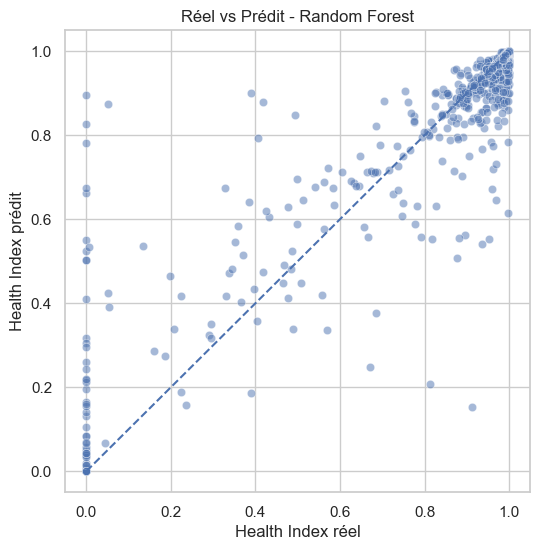

In [18]:
plt.figure(figsize=(6, 6))
sns.scatterplot(data=df_compare, x="y_true", y="y_pred", alpha=0.5)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title(f"Réel vs Prédit - {best_model_name}")
plt.xlabel("Health Index réel")
plt.ylabel("Health Index prédit")
plt.show()

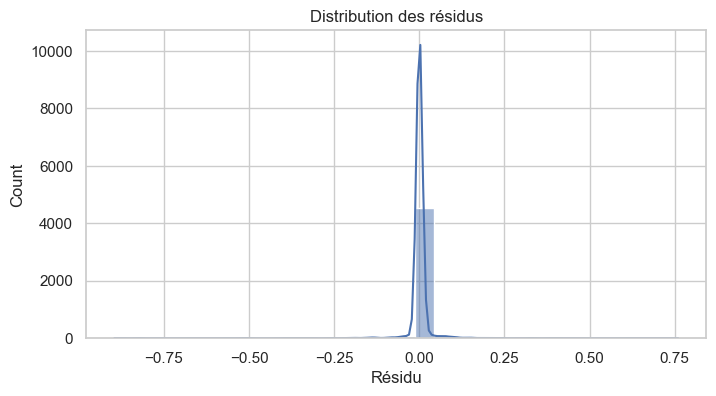

In [19]:
df_compare["residual"] = df_compare["y_true"] - df_compare["y_pred"]

plt.figure(figsize=(8, 4))
sns.histplot(df_compare["residual"], bins=30, kde=True)
plt.title("Distribution des résidus")
plt.xlabel("Résidu")
plt.show()

In [20]:
joblib.dump(best_model, "../models/health_index_ae_regressor.joblib")
print("Meilleur modèle sauvegardé.")

Meilleur modèle sauvegardé.


In [21]:
results_df.to_csv("../reports/model_comparison_health_index_ae.csv", index=False)
print("Tableau comparatif sauvegardé.")

Tableau comparatif sauvegardé.


## Conclusion de la modélisation du Health Score

Dans cette étape, nous avons entraîné et comparé plusieurs modèles de régression afin de prédire le **Health Score** des machines à partir des variables capteurs et des variables dérivées.

### Modèles testés

Nous avons évalué les modèles suivants :

* Régression Linéaire (baseline)
* Random Forest Regressor
* Gradient Boosting Regressor
* MLP Regressor (réseau de neurones)

### Analyse des performances

Les résultats obtenus montrent que tous les modèles atteignent de très bonnes performances, avec :

* une erreur moyenne (MAE) faible (~0.017),
* un RMSE faible (~0.02),
* un coefficient de détermination R² élevé (~0.95+).

La **régression linéaire obtient les meilleures performances**, ce qui indique que la relation entre les variables explicatives et le Health Score reste globalement **linéaire**, malgré l’introduction de non-linéarités et de bruit dans sa construction.

Les modèles plus complexes (Random Forest, Gradient Boosting, MLP) n’apportent pas d’amélioration significative, ce qui suggère que :

* le problème est bien structuré,
* les variables sélectionnées sont pertinentes,
* et que la complexité supplémentaire des modèles n’est pas nécessaire dans ce cas.

### Interprétation métier

Le Health Score, construit à partir des indicateurs physiques (vibration, température, pression, etc.) et de leur évolution dans le temps, est donc :

* **cohérent** avec les données,
* **prédictible** avec une bonne précision,
* et **suffisamment robuste** pour être utilisé dans un contexte décisionnel.

### Choix du modèle final

Au regard des performances et de la simplicité d’interprétation, la **régression linéaire est retenue comme modèle principal** pour la suite du projet.
Elle offre un excellent compromis entre :

* performance,
* rapidité,
* et interprétabilité.
